In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

In [10]:
# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [12]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сгруппируйте данные по дате, посчитайте количество продаж

In [ ]:
grouped_df = ...

In [14]:
grouped_df = df.groupby('Дата')['Количество'].sum().reset_index()

Вывести несколько первых строк сгруппированных данных

In [45]:
grouped_df.head()

,Дата,Количество
0,2018-01-04,3734
1,2018-01-05,3643
2,2018-01-06,3193
3,2018-01-07,3298
4,2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

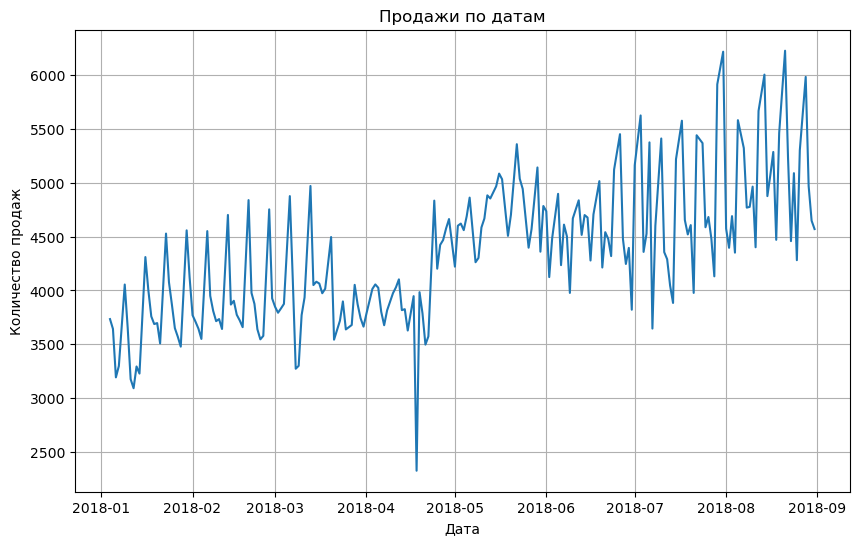

In [46]:
plt.figure(figsize=(10,6))
plt.plot(grouped_df['Дата'], grouped_df['Количество'])
plt.title('Продажи по датам')
plt.xlabel('Дата')
plt.ylabel('Количество продаж')
plt.grid()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

**На графике отображена динамика количества продаж по датам.
Видно, что продажи имеют неравномерный характер: наблюдаются как периоды роста, так и спады.
В некоторые даты присутствуют резкие пики — это может свидетельствовать о выбросах или аномально высоких продажах.
Общая тенденция может указывать на сезонность или влияние внешних факторов.**

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [47]:
df[df['Количество'] == df['Количество'].max()]

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [48]:
# фильтр
filtered = df[
    (df['Склад'] == 3) &
    (df['Дата'].dt.month.isin([6,7,8])) &
    (df['Дата'].dt.weekday == 2)  # среда = 2
]

# группировка
top_product = (
    filtered.groupby('Номенклатура')['Количество']
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

top_product

Номенклатура
product_1    2267
Name: Количество, dtype: int64

Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [49]:
weather = pd.read_csv(
    'weather.csv',
    sep=';',
    encoding='latin1',
    skiprows=6,
    on_bad_lines='skip'
)

In [50]:
weather.head()

,31.08.2018,"10,3"
0,31.08.2018,"10,8"
1,31.08.2018,"11,1"
2,30.08.2018,"17,1"
3,30.08.2018,"20,2"
4,30.08.2018,"19,3"


In [51]:
weather.columns

Index(['31.08.2018', '10,3'], dtype='object')

In [52]:
with open('weather.csv', encoding='utf-8', errors='ignore') as f:
    lines = f.readlines()

data_lines = [line for line in lines if not line.startswith('#')]

In [53]:
from io import StringIO

weather = pd.read_csv(
    StringIO(''.join(data_lines)),
    sep=';'
)

In [54]:
weather.head()

,Дата,T
0,31.08.2018,"9,6"
1,31.08.2018,"11,3"
2,31.08.2018,"12,3"
3,31.08.2018,"13,2"
4,31.08.2018,"12,5"


In [55]:
weather.columns

Index(['Дата', 'T'], dtype='object')

In [56]:
weather.rename(columns={'Местное время в Астане': 'Дата'}, inplace=True)

In [57]:
weather = weather[['Дата', 'T']]

In [58]:
weather.head()

,Дата,T
0,31.08.2018,"9,6"
1,31.08.2018,"11,3"
2,31.08.2018,"12,3"
3,31.08.2018,"13,2"
4,31.08.2018,"12,5"


In [59]:
weather['Дата'] = pd.to_datetime(weather['Дата'], format='%d.%m.%Y')

In [60]:
weather.head()

,Дата,T
0,2018-08-31,"9,6"
1,2018-08-31,"11,3"
2,2018-08-31,"12,3"
3,2018-08-31,"13,2"
4,2018-08-31,"12,5"


In [62]:
weather['T'] = weather['T'].str.replace(',', '.')

In [63]:
weather.head()

,Дата,T
0,2018-08-31,9.6
1,2018-08-31,11.3
2,2018-08-31,12.3
3,2018-08-31,13.2
4,2018-08-31,12.5


In [64]:
weather['T'] = weather['T'].astype(float)

In [65]:
weather.head()

,Дата,T
0,2018-08-31,9.6
1,2018-08-31,11.3
2,2018-08-31,12.3
3,2018-08-31,13.2
4,2018-08-31,12.5


In [66]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1918 entries, 0 to 1917
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Дата    1918 non-null   datetime64[ns]
 1   T       1918 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 30.1 KB


In [67]:
weather = weather.groupby('Дата')['T'].mean().reset_index()

In [68]:
weather.head()

,Дата,T
0,2018-01-04,-13.0875
1,2018-01-05,-17.2500
2,2018-01-06,-14.1250
3,2018-01-07,-12.3375
4,2018-01-08,-15.4375


In [69]:
merged = pd.merge(grouped_df, weather, on='Дата')

In [70]:
merged.shape
merged.head()

,Дата,Количество,T
0,2018-01-04,3734,-13.0875
1,2018-01-05,3643,-17.2500
2,2018-01-06,3193,-14.1250
3,2018-01-07,3298,-12.3375
4,2018-01-09,4055,-7.3875


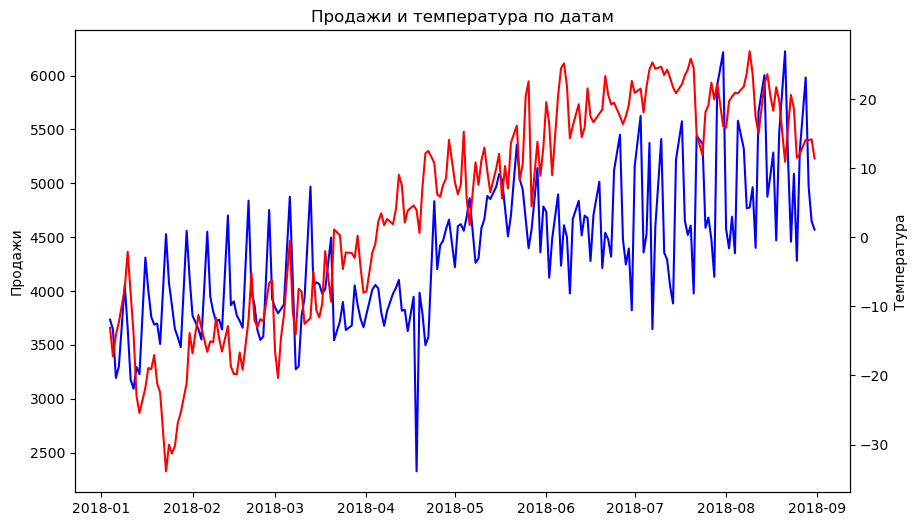

In [71]:
fig, ax1 = plt.subplots(figsize=(10,6))

# продажи
ax1.plot(merged['Дата'], merged['Количество'], color='blue')
ax1.set_ylabel('Продажи')

# температура
ax2 = ax1.twinx()
ax2.plot(merged['Дата'], merged['T'], color='red')
ax2.set_ylabel('Температура')

plt.title('Продажи и температура по датам')

plt.show()

*На графике представлена динамика количества продаж и средней температуры воздуха по дням. Температура агрегирована как среднее значение за день.*

*Продажи: наблюдаются регулярные пики и спады, что может быть связано с внутренними факторами (например, акции, спрос по дням недели или особенности бизнеса).*

*Температура, напротив, изменяется более плавно и демонстрирует общий восходящий тренд в течение рассматриваемого периода (переход от зимы к лету).*

*Явной линейной зависимости между температурой и объемом продаж не наблюдается. Однако в отдельных интервалах можно заметить совпадение направлений изменения показателей, что может указывать на наличие слабой или косвенной зависимости спроса от погодных условий.*

**Для подтверждения данной гипотезы требуется дополнительный количественный анализ (например, расчет корреляции).**